# URBAN 5160 - Graph Neural Networks for Urban Analytics: London Pollution Prediction

Word Count = 1200

Github = https://github.com/SammiGrewal/ATUA-2026-Assignment-2.git

________________________________________________________________________________

This project aims to build a graph neural network (GNN) to predict PM2.5 concentrtations for each output area in London. The notebook is split into the following sections:


1.   Exploratory Data Analysis
2.   Graph Construction
3.   GNN Model Building and Selection
4.   Results Analysis
5.   Conclusion and Reflection




In [103]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Exploratory Data Analysis**

In [ ]:
import geopandas as gpd
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm,colors
import seaborn as sns

from spreg import OLS
from sklearn.model_selection import train_test_split

import os
import torch
import torch.nn.functional as F

print("torch:", torch.__version__)

!pip -q install torch-geometric

from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv, SAGEConv

In [132]:
# Read in data file:
data = gpd.read_file("/content/AssignmentData-LondonPM25Prediction.geojson")

print("Columns:", list(data.columns))
print(data.shape)


Columns: ['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT', 'geometry']
(25053, 63)


The data file contains 63 columns of socio-economic characteristics for each OA in London. Only the following columns are kept for further analysis:

*   ### **Demographics**:
*   K001 - Age 0 - 4
*   K002 - Age 5 - 14
*   K005 - Age 65 - 89
*   K006 - Age 90+
*   K007 - Population density
*   K012 - White population

*   ### **Household Composition**:
*   K024 - No Children Household

*   ### **Housing**:
*   K031 - Owned or Shared Ownership
*   K032 - Social Rented
*   K033 - Private Rented

*   ### **Socio-Economic**:
*   K039 - Highest level of qualification: Level 4 and above
*   K041 - 2 or more cas or vans in household
*   K043 - Private Transport

*   ### **Employment**:
*   K045 - Unemployed
*   K046 - Part-time
*   K047 - Full-time

These variables are specifically kept to assess whether vulnerable populations are disproportinately exposed to higher amounts of pollution. For example, younger and older people are more susceptible to health complications arising from higher pollution. These variables can also help to assess inequalities, for example are areas where people own less cars (K041 & K043) more exposed to pollution even though they are less likely to drive.

In [133]:
columns_to_keep = ['oa_code',  'PM25', 'geometry', 'k001_PCT', 'k002_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k012_PCT', 'k024_PCT','k031_PCT', 'k032_PCT', 'k033_PCT', 'k039_PCT', 'k041_PCT', 'k043_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT']

data = data[columns_to_keep]
x_cols = ['oa_code', 'k001_PCT', 'k002_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k012_PCT', 'k024_PCT','k031_PCT', 'k032_PCT', 'k033_PCT', 'k039_PCT', 'k041_PCT', 'k043_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT']
y_col = ['oa_code', 'PM25']
# Check for null values
data.isnull().sum()

,0
oa_code,0
PM25,0
geometry,0
k001_PCT,0
k002_PCT,0
k005_PCT,0
k006_PCT,0
k007_RATIO,0
k012_PCT,0
k024_PCT,0


In [134]:
data.describe()

,PM25,k001_PCT,k002_PCT,k005_PCT,k006_PCT,k007_RATIO,k012_PCT,k024_PCT,k031_PCT,k032_PCT,k033_PCT,k039_PCT,k041_PCT,k043_PCT,k045_PCT,k046_PCT,k047_PCT
count,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000,25053.000000
mean,15.975608,0.641684,0.707470,0.562638,0.094603,0.475044,0.861921,0.703480,0.836013,0.588775,0.691187,0.689868,0.631367,0.733161,0.532456,0.644854,0.880514
std,0.783971,0.110625,0.130594,0.129298,0.113678,0.079349,0.111133,0.121152,0.129605,0.274221,0.151991,0.143944,0.187334,0.135083,0.140954,0.097468,0.049547
min,14.283266,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.403583,0.582274,0.657844,0.498177,0.000000,0.437683,0.810606,0.633432,0.774269,0.377915,0.599850,0.586357,0.503788,0.637167,0.446548,0.599234,0.854344
50%,15.846878,0.653091,0.736098,0.575978,0.067458,0.481625,0.893054,0.720494,0.865909,0.636587,0.713630,0.691734,0.649883,0.752086,0.547705,0.662267,0.882308
75%,16.428663,0.715548,0.792400,0.646634,0.141239,0.523587,0.943952,0.790217,0.932006,0.826883,0.805205,0.806498,0.780601,0.844707,0.634728,0.707769,0.911949
max,21.100099,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


There are no null values in the dataset and all columns show no inconsistencies. For example, all variables that are percentages or ratios have no value less than 0 or greater than 1, as expected.

## Plotting:


/tmp/ipykernel_9159/3707743978.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=10)


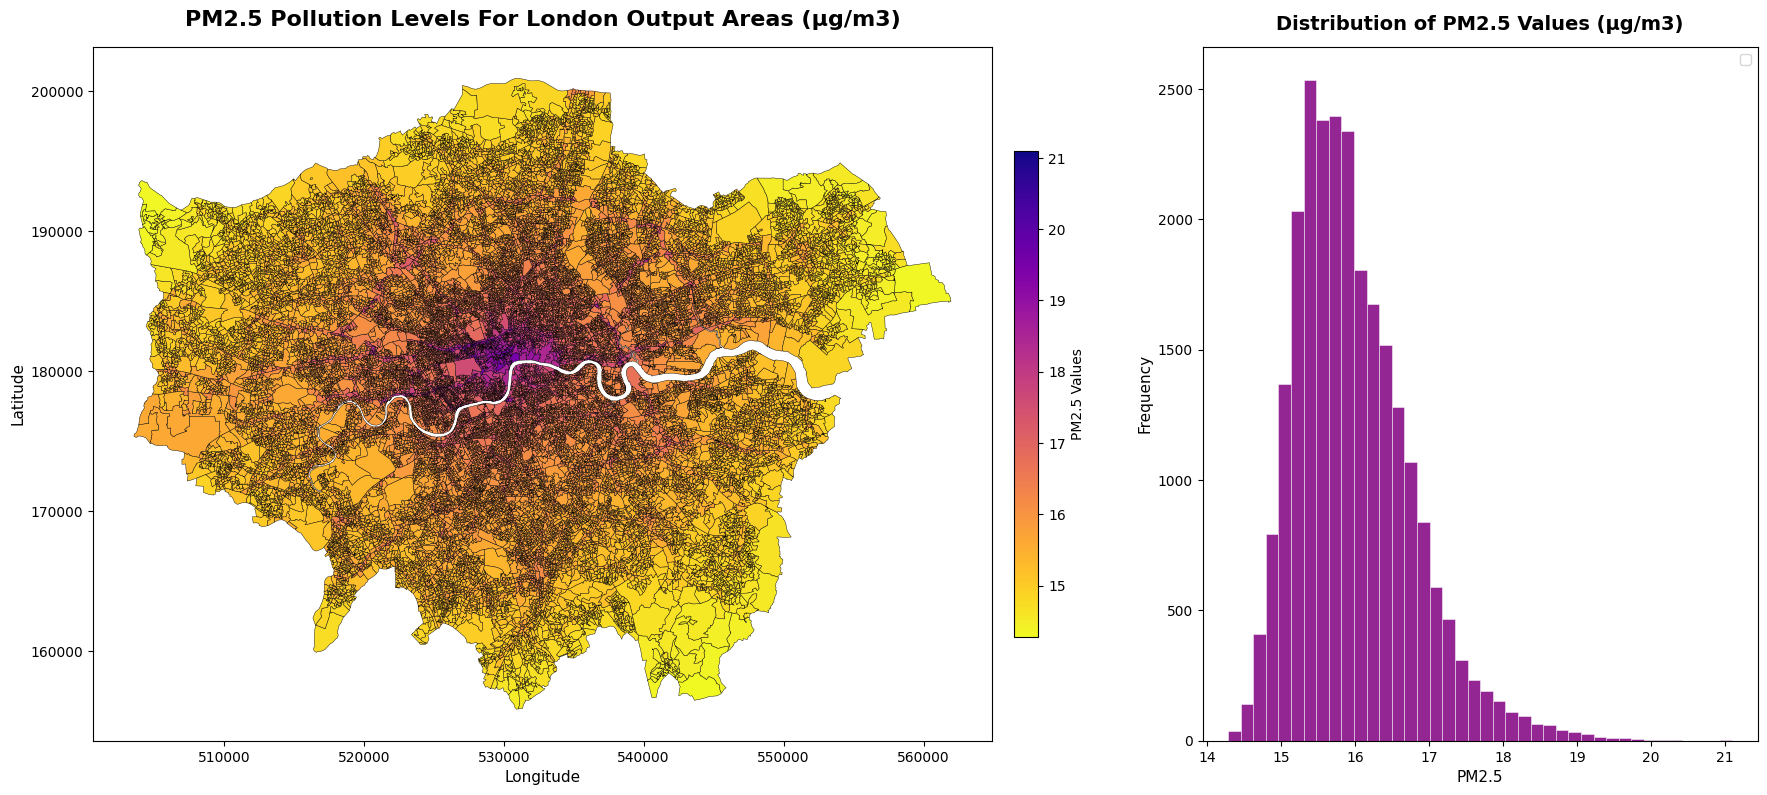

Number of high concentration areas: 6263


In [108]:
fig, (ax_map, ax_hist) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [2, 1]})

# Choropleth map of PM2.5 values:
data.plot(column='PM25',
          ax=ax_map, legend=True,
          cmap='plasma_r',
          edgecolor='black', linewidth=0.3,
          legend_kwds={'label': 'PM2.5 Values',
                       'orientation': 'vertical',
                       'shrink': 0.7,
                       'pad': 0.02}
          )
ax_map.set_title('PM2.5 Pollution Levels For London Output Areas (µg/m3)', fontsize=16, fontweight='bold', pad=15)
ax_map.set_xlabel('Longitude', fontsize=11)
ax_map.set_ylabel('Latitude', fontsize=11)

# Distribution of PM2.5 values:
ax_hist.hist(data['PM25'], bins=40, color='purple', edgecolor='white', linewidth=0.4, alpha=0.85)
ax_hist.set_title('Distribution of PM2.5 Values (µg/m3)', fontsize=14, fontweight='bold', pad=12)
ax_hist.set_xlabel('PM2.5', fontsize=11)
ax_hist.set_ylabel('Frequency', fontsize=11)
ax_hist.legend(fontsize=10)

plt.tight_layout()
plt.show()

high_PM25 = data['PM25'].quantile(0.75)
print(f"Number of high concentration areas: {len(data[data['PM25']> high_PM25])}")

The above plots show the choropleth map of PM2.5 concentrations in each London OA (left) and the histogram of PM2.5 values (right), respectively.

From the map, it is clear that areas where PM2.5 concentrations are greater (purple areas) are located in Central London, with lower concentrations (yellow areas) further away from Central London. Note that some OAs exhibit high concentrations outside of the center, this likely shows key transport networks such as roads running through such areas.

The distribution of PM2.5 values is right-skewed with a long right tail, which shows that high concentrations of PM2.5 are rare and located in only a few central locations. There are only 6263 areas where the PM2.5 concentration is greater than 75th percentile.

## **Graph Construction**

For this analysis, a Queen contiguity is used to ensure all touching neighbours of an output area are considered. This ensures edge and corner neighbours form the adjanceny graph for each output area. This is because output areas have irregular shapes, so not considering corners means that some neighbours are not included which would not be accurate.

This is important as pollution spreads out in all directions which includes cornering neighbours. So corners are important neighbours otherwise some data will go *missing*.

### Build Nodes:

In [109]:
def build_contiguity_graph(polys_gdf: gpd.GeoDataFrame, id_col: str, kind: str = "queen") -> nx.Graph:
    assert kind in {"queen", "rook"}
    Gc = nx.Graph()
    Gc.add_nodes_from(polys_gdf[id_col].tolist())

    sindex = polys_gdf.sindex
    geoms = polys_gdf.geometry.values
    ids = polys_gdf[id_col].values

    for i, geom_i in enumerate(geoms):
        cand_idx = list(sindex.intersection(geom_i.bounds))
        for j in cand_idx:
            if j <= i:
                continue
            geom_j = geoms[j]
            if kind == "queen":
                if geom_i.touches(geom_j):
                    Gc.add_edge(ids[i], ids[j])
            else:
                inter = geom_i.boundary.intersection(geom_j.boundary)
                if (not inter.is_empty) and getattr(inter, "length", 0.0) > 0:
                    Gc.add_edge(ids[i], ids[j])
    return Gc
data = data.copy()
data["geometry"] = data["geometry"].buffer(0)

contiguity = "queen"
G_poly = build_contiguity_graph(data, id_col="oa_code", kind=contiguity)

print("Contiguity:", contiguity, "| nodes:", G_poly.number_of_nodes(), "| edges:", G_poly.number_of_edges())
print("Connected components:", nx.number_connected_components(G_poly))

Contiguity: queen | nodes: 25053 | edges: 75967
Connected components: 1


In [110]:
# Feature variables (X) and target variables (Y) for each OA:
node_order = data["oa_code"].tolist()
x_data = data[x_cols].reset_index(drop=True)
y_data = data[y_col].reset_index(drop=True)

In [111]:
if 'oa_code' in x_data.columns:
    x_data.set_index('oa_code', inplace=True)

x_cols_without_oa_code = [col for col in x_cols if col != 'oa_code']
x_aligned = x_data.loc[node_order, x_cols_without_oa_code]

In [112]:
if 'oa_code' in y_data.columns:
    y_data.set_index('oa_code', inplace=True)

y_col_without_oa_code = [col for col in y_col if col != 'oa_code']
y_aligned = y_data.loc[node_order, y_col_without_oa_code]

In [113]:
X = torch.tensor(x_aligned.values, dtype=torch.float32)
y = torch.tensor(y_aligned.values, dtype=torch.float32).view(-1, 1)

print("X:", X.shape, "| y:", y.shape)

X: torch.Size([25053, 16]) | y: torch.Size([25053, 1])


In [114]:
def make_masks(num_nodes: int, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(num_nodes)
    rng.shuffle(idx)
    n_train = int(train_ratio * num_nodes)
    n_val = int(val_ratio * num_nodes)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

### Build Edges:

In [115]:
# Build edge_index in PyG format:
node_to_idx = {n:i for i,n in enumerate(node_order)}
edges = []
for u, v in G_poly.edges():
    edges.append((node_to_idx[u], node_to_idx[v]))
    edges.append((node_to_idx[v], node_to_idx[u]))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

data_poly = Data(x=X, edge_index=edge_index, y=y)
data_poly.train_mask, data_poly.val_mask, data_poly.test_mask = make_masks(data_poly.num_nodes, 0.6, 0.2, seed=42)
data_poly

Data(x=[25053, 16], edge_index=[2, 151934], y=[25053, 1], train_mask=[25053], val_mask=[25053], test_mask=[25053])

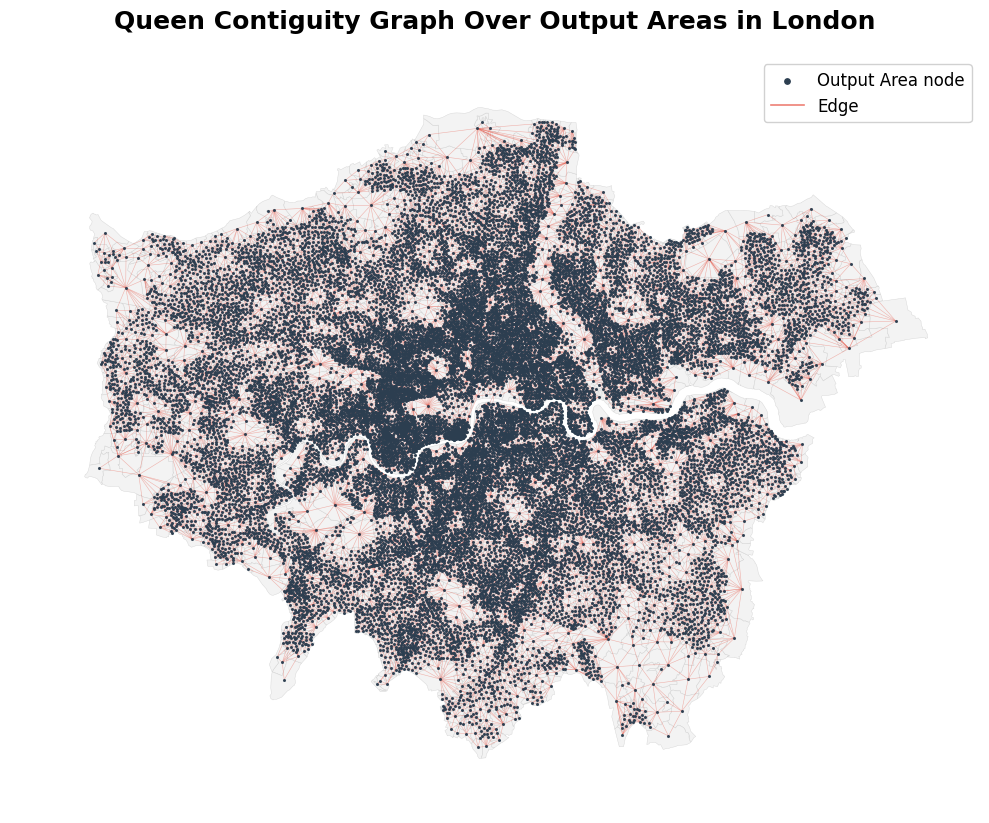

In [116]:
data["centroid"] = data.geometry.centroid
pos = {row["oa_code"]: (row["centroid"].x, row["centroid"].y) for _, row in data.iterrows()}
fig, ax = plt.subplots(figsize=(10, 10))

data.plot(ax=ax,
          edgecolor='#cccccc', linewidth=0.3,
          facecolor='#f0f0f0', alpha=0.8,
          )

# Edges:
nx.draw_networkx_edges(G_poly,
                       pos=pos,
                       ax=ax,
                       edge_color='#e74c3c', alpha=0.4,width=0.4
                       )

# Nodes:
nx.draw_networkx_nodes(G_poly,
                       pos=pos,
                       ax=ax,
                       node_size=1.5, node_color='#2c3e50', alpha=0.9
                       )

ax.set_title('Queen Contiguity Graph Over Output Areas in London',
             fontsize=18, fontweight='bold', pad=20
             )

# Legend:
legend_elements = [plt.scatter([], [], s=15, c='#2c3e50', label='Output Area node'),
                   plt.Line2D([0], [0], color='#e74c3c', linewidth=1.2, alpha=0.7, label='Edge')
                   ]
ax.legend(handles=legend_elements, fontsize=12, framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.show()

The nodes (and edges) follow the expected pattern with a greater density of nodes towards the centre of London and nodes becoming sparser towards the outskirts. This is because the output areas of inner London are much smaller and densely packed than outer London.

## **Graph Neural Network Model**

### Load Functions:

In [117]:
class SAGEReg(torch.nn.Module):
  def __init__(self, in_dim, hidden_dim=32, dropout=0.2, aggr="mean"):
      super().__init__()
      self.conv1 = SAGEConv(in_dim, hidden_dim, aggr=aggr)
      self.conv2 = SAGEConv(hidden_dim, 1, aggr=aggr)
      self.dropout = dropout

  def forward(self, x, edge_index):
      x = self.conv1(x, edge_index)
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)
      x = self.conv2(x, edge_index)
      return x

In [118]:
def evaluate_regression(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)
    def rmse(mask):
        return torch.sqrt(F.mse_loss(pred[mask], y[mask])).item()
    return rmse(data.train_mask), rmse(data.val_mask), rmse(data.test_mask)

def evaluate_regression_r2(model, data):
    model.eval()
    pred = model(data.x, data.edge_index).view(-1)
    y = data.y.view(-1)

    def r2(mask):
        y_true = y[mask]
        y_pred = pred[mask]
        ss_res = torch.sum((y_true - y_pred) ** 2)
        ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
        return (1 - ss_res / (ss_tot + 1e-12)).item()

    return r2(data.train_mask), r2(data.val_mask), r2(data.test_mask)

In [119]:
def plot_learning_curve(train_vals, val_vals, title, ylabel):
    plt.figure(figsize=(5.5, 3.2))
    plt.plot(train_vals, label="train")
    plt.plot(val_vals, label="val")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

In [120]:
def train_node_regression(model, data, lr=0.01, weight_decay=1e-4, epochs=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_rmse, val_rmse = [], []
    for epoch in range(1, epochs+1):
        model.train()
        optimizer.zero_grad()
        pred = model(data.x, data.edge_index).view(-1)
        y = data.y.view(-1)
        loss = F.mse_loss(pred[data.train_mask], y[data.train_mask])
        loss.backward()
        optimizer.step()

        r_train, r_val, _ = evaluate_regression(model, data)
        train_rmse.append(r_train)
        val_rmse.append(r_val)

        if epoch % 30 == 0:
            print(f"epoch {epoch:3d} | loss {loss.item():.4f} | rmse train {r_train:.4f} | val {r_val:.4f}")
    return train_rmse, val_rmse

### Initialise and train the GraphSAGE model:

In [ ]:
sage_reg_poly = SAGEReg(in_dim = data_poly.x.size(1), hidden_dim=64, dropout=0.2, aggr="mean")

train_rmse_sage_poly, val_rmse_sage_poly = train_node_regression(sage_reg_poly, data_poly, epochs=1000)


 Final (GraphSAGE) RMSE train/val/test: (0.3990713655948639, 0.3931465446949005, 0.3876948654651642)

 Final (GraphSAGE) R-squared train/val/test : (0.7456024289131165, 0.7451386451721191, 0.7445274591445923)


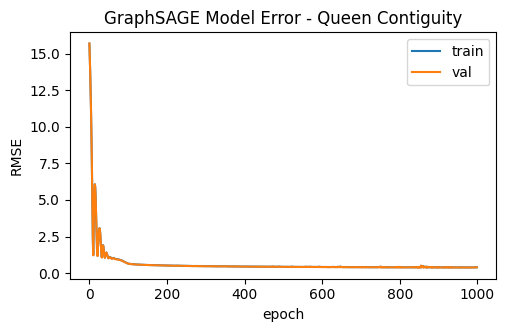

In [122]:
final_sage_rmse = evaluate_regression(sage_reg_poly, data_poly)
final_sage_R2 = evaluate_regression_r2(sage_reg_poly, data_poly)

print("\n Final (GraphSAGE) RMSE train/val/test:", final_sage_rmse)
print("\n Final (GraphSAGE) R-squared train/val/test :", final_sage_R2)

plot_learning_curve(train_rmse_sage_poly, val_rmse_sage_poly, "GraphSAGE Model Error - Queen Contiguity", "RMSE")

### Perform prediction using GraphSAGE model:

In [123]:
def predict_reg(model, data):
    model.eval()
    return model(data.x, data.edge_index).view(-1).cpu().detach()

# GraphSAGE prediction
data["pred_sage"] = predict_reg(sage_reg_poly, data_poly)

### Plot final result:

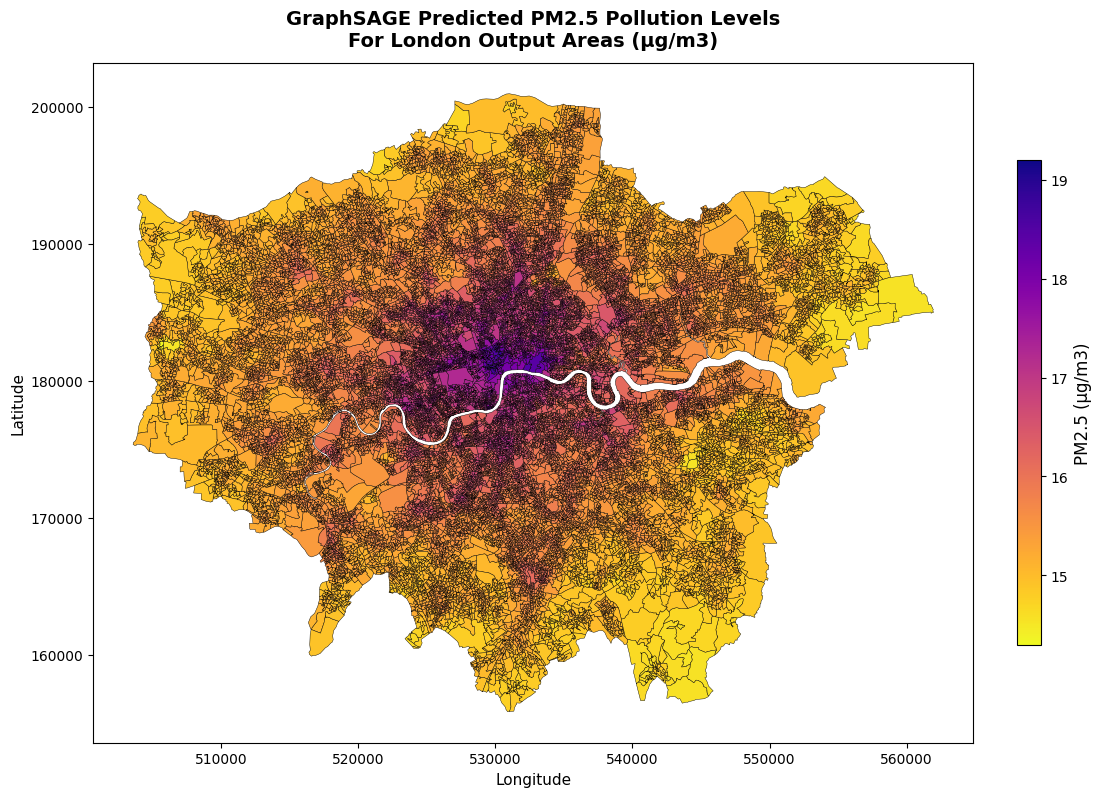

In [124]:
vmin = data['pred_sage'].min()
vmax = data['pred_sage'].max()

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# GraphSAGE predicited values
data.plot(column='pred_sage',
          cmap='plasma_r',
          edgecolor='black', linewidth=0.3,
          vmin = vmin, vmax = vmax,
          legend=False,
          ax=ax
          )
ax.set_title('GraphSAGE Predicted PM2.5 Pollution Levels\nFor London Output Areas (µg/m3)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)

# Legend
sm = cm.ScalarMappable(cmap='plasma_r', norm=colors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5, pad=0.04)
cbar.set_label('PM2.5 (µg/m3)', fontsize=12)

plt.tight_layout()
plt.show()

The GraphSAGE model looks to predict PM2.5 pollution levels reasonably well across London with similar spatial patterns to the actual data. For example, pollution is high in Central London and reduces gradually with greater distance from the centre.

However, there does seem to be some small inconsistencies, this is can be evaulated with a residuals plot, see below.

### Linear Regression

Compare GraphSAGE model to a simple linear regression prediction.

In [125]:
# Run OLS
X = data[x_cols_without_oa_code].values
y = data[y_col_without_oa_code].values.reshape(-1, 1)

ols = OLS(y, X,
          name_y=y_col_without_oa_code,
          name_x=x_cols_without_oa_code,
          name_ds='London Air Pollution'
          )

In [126]:
# Get predicted PM2.5 values from OLS:
data['pred_ols'] = ols.predy
# Get residuals from OLS:
data['resid_ols']   = ols.u
# Calculate GraphSAGE residuals:
data['resid_sage'] = data['PM25'] - data['pred_sage']

# OLS RMSE:
rmse_ols = np.sqrt(ols.sig2)

## **Results Analysis**

In [127]:
print(f"OLS RMSE: {rmse_ols}")
print(f"OLS R-squared: {ols.r2}")
print(f"\nGraphSAGE RMSE: {final_sage_rmse[2]}")
print(f"GraphSAGE R-squared: {final_sage_R2[2]}")

OLS RMSE: 0.43655756351373537
OLS R-squared: 0.6901115345957652

GraphSAGE RMSE: 0.3876948654651642
GraphSAGE R-squared: 0.7445274591445923


/tmp/ipykernel_9159/1586500828.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu")


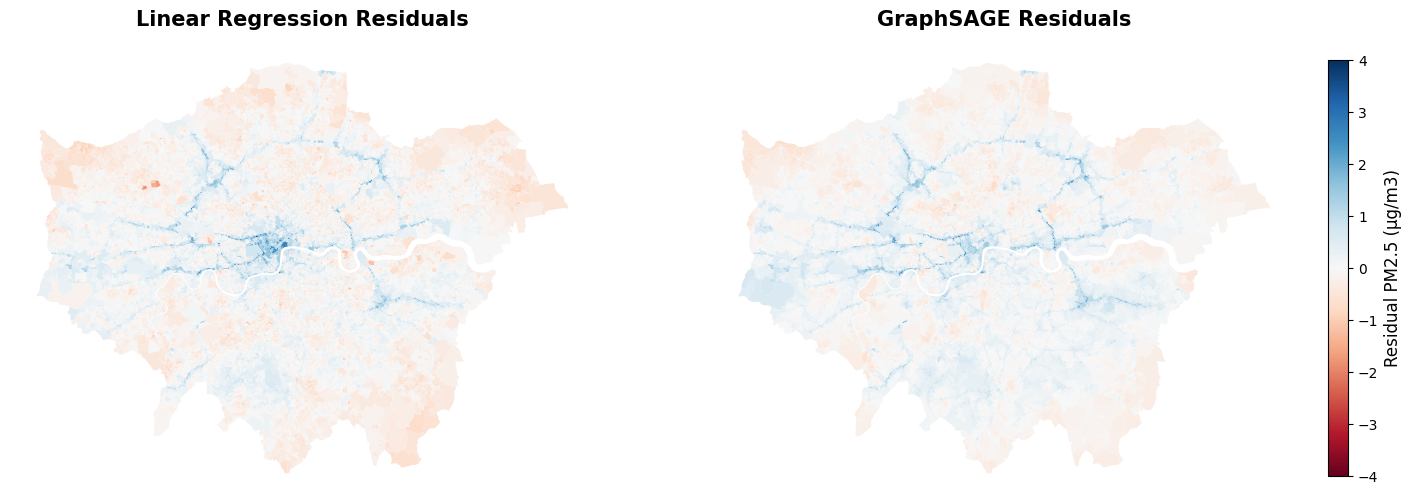

In [129]:
cmap = cm.get_cmap("RdBu")
norm = mcolors.TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

fig, (ax_resid_ols, ax_resid_sage) = plt.subplots(1, 2, figsize=(20, 9))

# Linear Regression Residuals:
data.plot(column='resid_ols',
          ax=ax_resid_lr,
          cmap=cmap, norm=norm,
          edgecolor='none',
          legend=False
          )
ax_resid_lr.set_title('Linear Regression Residuals', fontsize=15, fontweight='bold', pad=12)
ax_resid_lr.set_xlabel('Longitude', fontsize=11)
ax_resid_lr.set_ylabel('Latitude', fontsize=11)
ax_resid_lr.axis('off')

# GraphSAGE Residuals:
data.plot(column='resid_sage',
          ax=ax_resid_sage,
          cmap=cmap, norm=norm,
          edgecolor='none',
          legend=False
          )
ax_resid_sage.set_title('GraphSAGE Residuals', fontsize=15, fontweight='bold', pad=12)
ax_resid_sage.set_xlabel('Longitude', fontsize=11)
ax_resid_sage.set_ylabel('Latitude', fontsize=11)
ax_resid_sage.axis('off')

# Shared colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_resid_ols, ax_resid_sage], orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('Residual PM2.5 (µg/m3)', fontsize=12)

plt.show()

From the above evidence, we can conclude thet the GraphSAGE model performs better than the baseline linear regression model. The R<sup>2</sup> for GraphSAGE, R<sup>2</sup><sub>SAGE</sub> = 0.74, is higher than linear regression, R<sup>2</sup><sub>LR</sub> = 0.69. Also, the GraphSAGE RMSE, RMSE<sub>SAGE</sub> = 0.39, is less than linear regression, RMSE<sub>LR</sub> = 0.44 . Together this means that the GNN model offers greater explantatory power and makes more accurate predictions than the baseline model.

However, both models are not perfect. Looking at the residuals plot, above, the GraphSAGE model appears to underestimate PM<sub>2.5</sub> values towards the center of London and whilst the model performs better in outer London, it still overpredicts values in some areas, especially on the London boundary. GraphSAGE residuals appeared more spatially random than those of the linear
regression, which is further evidence that the graph structure facilitated a better model than linear regression.

One thing to note is that both models look to underestimate pollution along key road networks throughout London. For example the blue lines extending west from Central London and the semi-circular path in North London look to be key aerterial roads. Therefore, the reason why the GNN model underpredicts values in Central London is because of the dense road network in this area - which the model does not account for. As a result, the GraphSAGE model is likely to benefit significantly by incorporating data on the road (and/or wider transport) networks as part of graph structure.

Incorporating key transport networks into the GNN model can also allow for the links between output areas that are connected by transport networks to be included rather than just the nearest neighbours. For example, two output areas that do not share a boundary, but are connected by a main road could be classed as neighbours if the transport network was accounted for. This could help increase the performance of the GraphSAGE model.

## **Conclusion and Reflection**

Nonetheless, the GraphSAGE model signficantly outperforms the simple regression model which shows the power of GNNs and the importance of incorporating spatial structure into urban models.

As previously mentioned, the Queen adjacency matrix was preffered of Rock as it better represents the geometric structure of London's output areas (OAs). As the OAs are irregular and dense, the majority of them will have neighbours at their corners and the shared edges. Rock contiguities would not account for this geometric structure producing a sparser and
less representative graph.

Model Selection: GraphSAGE
GraphSAGE was chosen over a standard Graph Convolutional Network (GCN).This is because the data contains 25053 OAs, the GCN model would be far too computationally expensive to run as all areas are used in the model fit. Whereas GraphSAGE relies on sampled subset of neighbours at each layer, which means it can handle larger graphs more easily.

The GraphSAGE model was implemented with two layers, meaning the model uses a node's neighbours and its neighbour's neighbours. This is good as it allows for the diffusion of pollution to be, somewhat, incorporated into the fit. As pollution spreads out into the air after it is emitted, it is important to capture this behaviour as pollution emitted in one OA will impact nearby OAs as well.

As mentioned above, incorporating the underlying road network and information such as road density and distance to A-roads for each OA, is likely to improve model performance and predictive power, especially along transport corridors.
